--- Loading Data ---
Initial shape: (40005, 43)

--- Data Integrity Checks ---
Duplicate AppIDs found: 0
Missing values per column:
AppID                       0
Name                        0
Release date                0
required_age                0
Price                       0
DLC count                   0
detailed_description        0
about_the_game              0
short_description           0
reviews                     0
header_image                0
website                     0
support_url                 0
support_email               0
Windows                     0
Mac                         0
Linux                       0
Metacritic score            0
metacritic_url              0
Achievements                0
recommendations             0
notes                       0
supported_languages         0
full_audio_languages        0
packages                    0
Developers                  0
Publishers                  0
categories                  0
Genres                      

,AppID,Name,Release date,required_age,Price,DLC count,detailed_description,about_the_game,short_description,reviews,...,Estimated owners,Average playtime forever,average_playtime_2weeks,Median playtime forever,median_playtime_2weeks,discount,Peak CCU,Tags,Release Year,owners_rank
0,1964380,My little sister: Prologue,2022-05-13,0,0.00,0,"Synopsis Suhan, a high school student, feels f...","Synopsis Suhan, a high school student, feels f...",😒😐🤨😉🥰😨😈 The girl of my dreams,,...,0 - 20K,0,0,0,0,0,0,,2022,0
1,1840920,SEARCH ALL - FOXES,NaT,0,2.99,0,SEARCH ALL - FOXES is a game in the genre of '...,SEARCH ALL - FOXES is a game in the genre of '...,"Is a game in the genre of 'hidden object', in ...",,...,20K - 50K,0,0,0,0,80,0,"Exploration,Trading Card Game,Flight,Clicker,C...",0,1
2,1591670,Mark & Lara: Partners In Justice,NaT,0,4.99,0,A CO-OP DETECTIVE EXPERIENCE. An adventure for...,A CO-OP DETECTIVE EXPERIENCE. An adventure for...,Call your partner and become the best detectiv...,,...,0 - 20K,0,0,0,0,0,0,"Online Co-Op,Co-op,Co-op Campaign,Local Co-Op,...",0,0
4,2102530,Mega Fast Food: A Fast Food Simulator Game,NaT,0,13.99,0,"Wishlist Now About the Game Mega Fast Food , i...","Mega Fast Food , is a simulation management ga...",Build and manage your own fast food store. Dec...,,...,0 - 20K,0,0,0,0,0,0,"Simulation,Management,City Builder,Building,Sa...",0,0
5,1335790,Operation: Tango,NaT,0,6.79,1,FRIEND PASS About the Game Join our Discord Se...,Join our Discord Server NOTES: - This game is ...,It takes two to save the world in this coopera...,“Operation: Tango is a clever and appealing ta...,...,500K - 1M,343,507,273,507,66,30,"Online Co-Op,Puzzle,Co-op Campaign,Adventure,C...",0,5


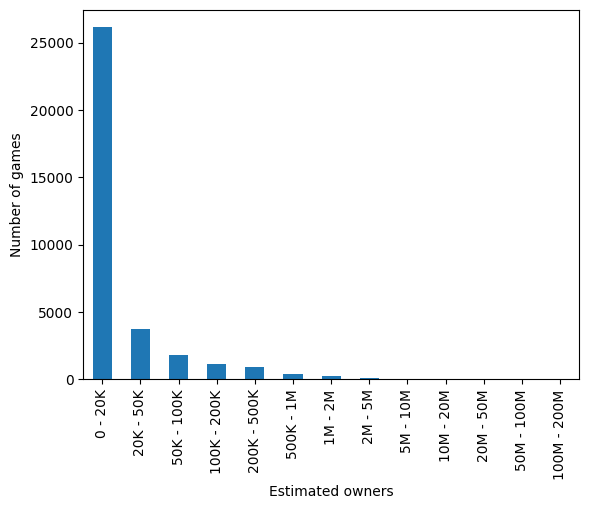

In [ ]:
import numpy as np
import pandas as pd

print("--- Loading Data ---")
df = pd.read_json('/Users/patrickrinn/Library/CloudStorage/OneDrive-UBC/COSC 301/project/project2/games.json')
df = df.T # transpose the dataframe
df = df.reset_index(names='AppID')

print(f"Initial shape: {df.shape}")

# basic rename and column cleaning
column_mapping = {
    'name': 'Name',
    'release_date': 'Release date',
    'estimated_owners': 'Estimated owners',
    'peak_ccu': 'Peak CCU',
    'price': 'Price',
    'dlc_count': 'DLC count',
    'windows': 'Windows',
    'mac': 'Mac',
    'linux': 'Linux',
    'metacritic_score': 'Metacritic score',
    'positive': 'Positive',
    'negative': 'Negative',
    'achievements': 'Achievements',
    'average_playtime_forever': 'Average playtime forever',
    'median_playtime_forever': 'Median playtime forever',
    'developers': 'Developers',
    'publishers': 'Publishers',
    'genres': 'Genres',
    'tags': 'Tags'
}

df = df.rename(columns=column_mapping)

# 2. data integrity: duplicates and missing values
print("\n--- Data Integrity Checks ---")
duplicates = df.duplicated(subset=['AppID']).sum()
print(f"Duplicate AppIDs found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates(subset=['AppID'])

print("Missing values per column:")
print(df.isnull().sum())

# type conversions
print("\n--- Performing Type Conversions ---")

# numeric conversion helper
numeric_cols = [
    'Price', 'Positive', 'Negative', 'Peak CCU', 'DLC count', 
    'Metacritic score', 'Achievements', 'Median playtime forever', 
    'Average playtime forever'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# platform columns 
for plat in ['Windows', 'Mac', 'Linux']:
    df[plat] = df[plat].astype(int)

# date conversion
df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
df['Release Year'] = df['Release date'].dt.year.fillna(0).astype(int)

def clean_tags(x):
    # 1. if it's a dictionary, extract and join the keys
    if isinstance(x, dict):
        return ','.join(str(k) for k in x.keys())
    
    # 2. if it's an array or list (the source of the error), join it or return empty
    if isinstance(x, (list, np.ndarray)):
        return ','.join(map(str, x)) if len(x) > 0 else ''
        
    # 3. safely check for NaN/None
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ''
        
    # 4. fallback for standard strings, integers, etc.
    return str(x)

# comma-separated strings for lists
if 'Genres' in df.columns:
    df['Genres'] = df['Genres'].apply(clean_tags)
if 'Tags' in df.columns:
    df['Tags'] = df['Tags'].apply(clean_tags)

# 4. categorical cleaning
df = df[df['Estimated owners'] != '0 - 0'] # these games are likely deleted/playtests, so we will be better off not using them.


owner_label_map = {             # easier to read with shortened
    '0 - 20000': '0 - 20K', 
    '20000 - 50000': '20K - 50K', 
    '50000 - 100000': '50K - 100K', 
    '100000 - 200000': '100K - 200K', 
    '200000 - 500000': '200K - 500K', 
    '500000 - 1000000': '500K - 1M', 
    '1000000 - 2000000': '1M - 2M', 
    '2000000 - 5000000': '2M - 5M', 
    '5000000 - 10000000': '5M - 10M', 
    '10000000 - 20000000': '10M - 20M', 
    '20000000 - 50000000': '20M - 50M', 
    '50000000 - 100000000': '50M - 100M', 
    '100000000 - 200000000': '100M - 200M'
}
df['Estimated owners'] = df['Estimated owners'].map(owner_label_map)

# create numeric rank for sorting categories
owner_order_k = list(owner_label_map.values())
owner_rank_map = {val: i for i, val in enumerate(owner_order_k)}
df['owners_rank'] = df['Estimated owners'].map(owner_rank_map)

for col in df.columns:
    # check if any row in this column is a list or dict for SQLite compatibility
    if df[col].map(lambda x: isinstance(x, (list, dict))).any():
        df[col] = df[col].astype(str)

print(f"\nFinal Cleaned Shape: {df.shape}")

df['Estimated owners'].value_counts().plot.bar(ylabel='Number of games') # plot to visualize ownership
df.head()

In [11]:
import sqlite3
conn = sqlite3.connect('steam_games.db')
df.to_sql('cleaned_games', conn, if_exists='replace', index=False)
conn.close()
print("Database updated successfully.")

Database updated successfully.
